# German Credit

- **A0**: Value transformation of 13 distinct columns from codes to interpretable terms.  
- **A1**: Generation of two new columns `gender`, `status` from the column `personal_status`.  
- **A2**: The column `personal_status` was deleted.  
- **A3**: 11 categorical columns were OneHot encoded.  


In [1]:
# !pip install ucimlrepo -q

In [2]:
# Load data
import pandas as pd
from ucimlrepo import fetch_ucirepo 

statlog_german_credit_data = fetch_ucirepo(id=144) 
  
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets
german_df = pd.concat([X, y], axis=1)

In [3]:
from tensor_prov import Provenance

prov = Provenance(save_dir=f"results_german", verbose=2)
german_wdf = prov.subscribe(german_df)
german_wdf

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


In [4]:
# A0: Value transformation of 13 distinct columns from codes to interpretable terms.
import re

variable_info = statlog_german_credit_data.metadata["additional_info"]["variable_info"]
distinct_cols = re.findall(r"(A.*\d+):.*?\(qualitative\)", variable_info)
print("distinct_cols:", distinct_cols)
print("len(distinct_cols):", len(distinct_cols))
matches = re.findall(r"(A\d+)\s*:\s*([^\n\r]+)", variable_info)
mapping = {code: desc for code, desc in matches}

german_wdf = german_wdf.replace(mapping)
german_wdf

distinct_cols: ['Attribute 1', 'Attribute 3', 'Attribute 4', 'Attibute 6', 'Attribute 7', 'Attribute 9', 'Attribute 10', 'Attribute 12', 'Attribute 14', 'Attribute 15', 'Attribute 17', 'Attribute 19', 'Attribute 20']
len(distinct_cols): 13
-- id_in -> id_out--
 1 -> 2
-- tensor_record --
 [[  0   0]
 [  1   1]
 [  2   2]
 ...
 [997 997]
 [998 998]
 [999 999]]
-- tensor_attr --
 [[ 0  0]
 [ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 6  6]
 [ 7  7]
 [ 8  8]
 [ 9  9]
 [10 10]
 [11 11]
 [12 12]
 [13 13]
 [14 14]
 [15 15]
 [16 16]
 [17 17]
 [18 18]
 [19 19]
 [20 20]]


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,... < 0 DM,6,critical account/ other credits existing (not...,radio/television,1169,unknown/ no savings account,.. >= 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,none,yes,1
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes,1
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,... < 100 DM,4 <= ... < 7 years,3,female : divorced/separated/married,none,...,real estate,31,none,own,1,unskilled - resident,1,none,yes,1
996,... < 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male : divorced/separated,none,...,if not A121 : building society savings agreeme...,40,none,own,1,management/ self-employed/,1,"yes, registered under the customers name",yes,1
997,no checking account,12,existing credits paid back duly till now,radio/television,804,... < 100 DM,.. >= 7 years,4,male : single,none,...,"if not A121/A122 : car or other, not in attrib...",38,none,own,1,skilled employee / official,1,none,yes,1
998,... < 0 DM,45,existing credits paid back duly till now,radio/television,1845,... < 100 DM,1 <= ... < 4 years,4,male : single,none,...,unknown / no property,23,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2


In [5]:
# A1: Generation of two new columns gender, status from the column personal_status.
german_wdf[["gender", "status"]] = german_wdf["Attribute9"].str.split(":", expand=True)
german_wdf

-- id_in -> id_out--
 2 -> 3
-- tensor_record --
 [[  0   0]
 [  1   1]
 [  2   2]
 ...
 [997 997]
 [998 998]
 [999 999]]
-- tensor_attr --
 [[ 0  0]
 [ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 6  6]
 [ 7  7]
 [ 8  8]
 [ 9  9]
 [10 10]
 [11 11]
 [12 12]
 [13 13]
 [14 14]
 [15 15]
 [16 16]
 [17 17]
 [18 18]
 [19 19]
 [20 20]]


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class,gender,status
0,... < 0 DM,6,critical account/ other credits existing (not...,radio/television,1169,unknown/ no savings account,.. >= 7 years,4,male : single,none,...,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,male,single
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,none,own,1,skilled employee / official,1,none,yes,2,female,divorced/separated/married
2,no checking account,12,critical account/ other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,none,own,1,unskilled - resident,2,none,yes,1,male,single
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,none,for free,1,skilled employee / official,2,none,yes,1,male,single
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,none,for free,2,skilled employee / official,2,none,yes,2,male,single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,... < 100 DM,4 <= ... < 7 years,3,female : divorced/separated/married,none,...,none,own,1,unskilled - resident,1,none,yes,1,female,divorced/separated/married
996,... < 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,male : divorced/separated,none,...,none,own,1,management/ self-employed/,1,"yes, registered under the customers name",yes,1,male,divorced/separated
997,no checking account,12,existing credits paid back duly till now,radio/television,804,... < 100 DM,.. >= 7 years,4,male : single,none,...,none,own,1,skilled employee / official,1,none,yes,1,male,single
998,... < 0 DM,45,existing credits paid back duly till now,radio/television,1845,... < 100 DM,1 <= ... < 4 years,4,male : single,none,...,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2,male,single


In [6]:
# A2: The column personal_status was deleted.  
german_wdf = german_wdf.drop(columns=["Attribute9"])
german_wdf

-- id_in -> id_out--
 3 -> 4
-- tensor_record --
 [[  0   0]
 [  1   1]
 [  2   2]
 ...
 [997 997]
 [998 998]
 [999 999]]
-- tensor_attr --
 [[ 0  0]
 [ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 6  6]
 [ 7  7]
 [ 8  9]
 [ 9 10]
 [10 11]
 [11 12]
 [12 13]
 [13 14]
 [14 15]
 [15 16]
 [16 17]
 [17 18]
 [18 19]
 [19 20]
 [20 21]
 [21 22]]


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute10,Attribute11,...,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class,gender,status
0,... < 0 DM,6,critical account/ other credits existing (not...,radio/television,1169,unknown/ no savings account,.. >= 7 years,4,none,4,...,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,male,single
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,none,2,...,none,own,1,skilled employee / official,1,none,yes,2,female,divorced/separated/married
2,no checking account,12,critical account/ other credits existing (not...,education,2096,... < 100 DM,4 <= ... < 7 years,2,none,3,...,none,own,1,unskilled - resident,2,none,yes,1,male,single
3,... < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,... < 100 DM,4 <= ... < 7 years,2,guarantor,4,...,none,for free,1,skilled employee / official,2,none,yes,1,male,single
4,... < 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,none,4,...,none,for free,2,skilled employee / official,2,none,yes,2,male,single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,... < 100 DM,4 <= ... < 7 years,3,none,4,...,none,own,1,unskilled - resident,1,none,yes,1,female,divorced/separated/married
996,... < 0 DM,30,existing credits paid back duly till now,car (used),3857,... < 100 DM,1 <= ... < 4 years,4,none,4,...,none,own,1,management/ self-employed/,1,"yes, registered under the customers name",yes,1,male,divorced/separated
997,no checking account,12,existing credits paid back duly till now,radio/television,804,... < 100 DM,.. >= 7 years,4,none,4,...,none,own,1,skilled employee / official,1,none,yes,1,male,single
998,... < 0 DM,45,existing credits paid back duly till now,radio/television,1845,... < 100 DM,1 <= ... < 4 years,4,none,4,...,none,for free,1,skilled employee / official,1,"yes, registered under the customers name",yes,2,male,single


In [7]:
# A3: 11 categorical columns were OneHot encoded.  
import tensor_prov.watched_pandas as wpd

variables_df = statlog_german_credit_data.variables
categorical_cols = variables_df.loc[variables_df["type"] == "Categorical", "name"].tolist()
categorical_cols = ["status" if col == "Attribute9" else col for col in categorical_cols]
print("categorical_cols:", categorical_cols)
print("len(categorical_cols):", len(categorical_cols))

german_wdf = wpd.get_dummies(german_wdf, columns=categorical_cols, dtype=int)
german_wdf

categorical_cols: ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'status', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17']
len(categorical_cols): 11
-- id_in -> id_out--
 4 -> 5
-- tensor_record --
 [[  0   0]
 [  1   1]
 [  2   2]
 ...
 [997 997]
 [998 998]
 [999 999]]
-- tensor_attr --
 [[ 0  1]
 [ 1  4]
 [ 2  7]
 [ 3  9]
 [ 4 11]
 [ 5 14]
 [ 6 16]
 [ 7 17]
 [ 8 18]
 [ 9 19]
 [10 20]
 [11  0]
 [12  0]
 [13  0]
 [14  0]
 [15  2]
 [16  2]
 [17  2]
 [18  2]
 [19  2]
 [20  3]
 [21  3]
 [22  3]
 [23  3]
 [24  3]
 [25  3]
 [26  3]
 [27  3]
 [28  3]
 [29  3]
 [30  5]
 [31  5]
 [32  5]
 [33  5]
 [34  5]
 [35  6]
 [36  6]
 [37  6]
 [38  6]
 [39  6]
 [40 21]
 [41 21]
 [42 21]
 [43 21]
 [44  8]
 [45  8]
 [46  8]
 [47 10]
 [48 10]
 [49 10]
 [50 10]
 [51 12]
 [52 12]
 [53 12]
 [54 13]
 [55 13]
 [56 13]
 [57 15]
 [58 15]
 [59 15]
 [60 15]]


,Attribute2,Attribute5,Attribute8,Attribute11,Attribute13,Attribute16,Attribute18,Attribute19,Attribute20,class,...,Attribute14_bank,Attribute14_none,Attribute14_stores,Attribute15_for free,Attribute15_own,Attribute15_rent,Attribute17_management/ self-employed/,Attribute17_skilled employee / official,Attribute17_unemployed/ unskilled - non-resident,Attribute17_unskilled - resident
0,6,1169,4,4,67,2,1,"yes, registered under the customers name",yes,1,...,0,1,0,0,1,0,0,1,0,0
1,48,5951,2,2,22,1,1,none,yes,2,...,0,1,0,0,1,0,0,1,0,0
2,12,2096,2,3,49,1,2,none,yes,1,...,0,1,0,0,1,0,0,0,0,1
3,42,7882,2,4,45,1,2,none,yes,1,...,0,1,0,1,0,0,0,1,0,0
4,24,4870,3,4,53,2,2,none,yes,2,...,0,1,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,none,yes,1,...,0,1,0,0,1,0,0,0,0,1
996,30,3857,4,4,40,1,1,"yes, registered under the customers name",yes,1,...,0,1,0,0,1,0,1,0,0,0
997,12,804,4,4,38,1,1,none,yes,1,...,0,1,0,0,1,0,0,1,0,0
998,45,1845,4,4,23,1,1,"yes, registered under the customers name",yes,2,...,0,1,0,1,0,0,0,1,0,0


In [8]:
operations_A = ["A0", "A1", "A2", "A3"]
runtimes_A = {}
for op, rt in zip(operations_A, prov.runtimes):
    runtimes_A[op] = runtimes_A.get(op, 0) + rt
runtimes_A

{'A0': 0.011969327926635742,
 'A1': 0.02000594139099121,
 'A2': 0.014194488525390625,
 'A3': 0.010880231857299805}

# Compas Score
- **B0**: Selection of 9 relevant columns.  
- **B1**: Missing values were deleted.  
- **B2**: The column `race` was binarized.  
- **B3**: Value transformation of the column `label` for consistency.  
- **B4**: Conversion of `c_jail_in` and `c_jail_out` columns to `days`.  
- **B5**: Drop `c_jail_in` and `c_jail_out` dates.  
- **B6**: Value transformation of column `c_charge_degree`.  

In [9]:
# Load data
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas_df = pd.read_csv(url)

In [10]:
from tensor_prov.provenance_coo import Provenance

prov = Provenance(save_dir=f"results_compas", verbose=2)
compas_wdf = prov.subscribe(compas_df)
compas_wdf

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0


In [11]:
# B0: Selection of 9 relevant columns.
relevant_cols = [
    "age", "c_charge_degree", "race", "sex", "priors_count", 
    "days_b_screening_arrest", "two_year_recid", "c_jail_in", "c_jail_out"
]

compas_wdf = compas_wdf[relevant_cols]
compas_wdf

-- id_in -> id_out--
 1 -> 2
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [7211 7211]
 [7212 7212]
 [7213 7213]]
-- tensor_attr --
 [[ 0  7]
 [ 1 22]
 [ 2  9]
 [ 3  5]
 [ 4 14]
 [ 5 15]
 [ 6 52]
 [ 7 16]
 [ 8 17]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Male,0,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,Male,0,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Male,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04
3,23,F,African-American,Male,1,NaN,0,NaN,NaN
4,43,F,Other,Male,2,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7209,23,F,African-American,Male,0,-1.0,0,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,African-American,Male,0,-1.0,0,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,Other,Male,0,-1.0,0,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,African-American,Female,3,-1.0,0,2014-03-08 08:06:02,2014-03-09 12:18:04


In [12]:
# B1: Missing values were deleted.
compas_wdf = compas_wdf.dropna()
compas_wdf

-- id_in -> id_out--
 2 -> 3
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 7211]
 [6905 7212]
 [6906 7213]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]
 [8 8]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,two_year_recid,c_jail_in,c_jail_out
0,69,F,Other,Male,0,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,African-American,Male,0,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,African-American,Male,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,Other,Male,0,0.0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,Caucasian,Male,14,-1.0,1,2014-02-18 05:08:24,2014-02-24 12:18:30
...,...,...,...,...,...,...,...,...,...
7209,23,F,African-American,Male,0,-1.0,0,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,African-American,Male,0,-1.0,0,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,Other,Male,0,-1.0,0,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,African-American,Female,3,-1.0,0,2014-03-08 08:06:02,2014-03-09 12:18:04


In [13]:
# B2: The column race was binarized.
compas_wdf["race"] = [0 if r != "Caucasian" else 1 for r in compas_wdf["race"]]
compas_wdf

-- id_in -> id_out--
 3 -> 4
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 6904]
 [6905 6905]
 [6906 6906]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]
 [8 8]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,two_year_recid,c_jail_in,c_jail_out
0,69,F,0,Male,0,-1.0,0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,0,Male,0,-1.0,1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,0,Male,4,-1.0,1,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,0,Male,0,0.0,0,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,1,Male,14,-1.0,1,2014-02-18 05:08:24,2014-02-24 12:18:30
...,...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,0,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,0,Male,0,-1.0,0,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,0,Male,0,-1.0,0,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,0,Female,3,-1.0,0,2014-03-08 08:06:02,2014-03-09 12:18:04


In [14]:
# B3: Value transformation of the column label for consistency.
compas_wdf = compas_wdf.rename({"two_year_recid": "label"}, axis=1)
compas_wdf["label"] = [0 if l == 1 else 1 for l in compas_wdf["label"]]  # Reverse label for consistency: 1 means no recid (good), 0 means recid (bad)
compas_wdf

-- id_in -> id_out--
 4 -> 5
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 6904]
 [6905 6905]
 [6906 6906]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]
 [8 8]]
-- id_in -> id_out--
 5 -> 6
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 6904]
 [6905 6905]
 [6906 6906]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]
 [8 8]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,c_jail_in,c_jail_out
0,69,F,0,Male,0,-1.0,1,2013-08-13 06:03:42,2013-08-14 05:41:20
1,34,F,0,Male,0,-1.0,0,2013-01-26 03:45:27,2013-02-05 05:36:53
2,24,F,0,Male,4,-1.0,0,2013-04-13 04:58:34,2013-04-14 07:02:04
5,44,M,0,Male,0,0.0,1,2013-11-30 04:50:18,2013-12-01 12:28:56
6,41,F,1,Male,14,-1.0,0,2014-02-18 05:08:24,2014-02-24 12:18:30
...,...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,1,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,23,F,0,Male,0,-1.0,1,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,57,F,0,Male,0,-1.0,1,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,33,M,0,Female,3,-1.0,1,2014-03-08 08:06:02,2014-03-09 12:18:04


In [15]:
# B4:  Conversion of c_jail_in and c_jail_out columns to days.
compas_wdf["jailtime"] = (pd.to_datetime(compas_wdf.c_jail_out) - pd.to_datetime(compas_wdf.c_jail_in)).dt.days
compas_wdf

-- id_in -> id_out--
 6 -> 7
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 6904]
 [6905 6905]
 [6906 6906]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]
 [8 8]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,c_jail_in,c_jail_out,jailtime
0,69,F,0,Male,0,-1.0,1,2013-08-13 06:03:42,2013-08-14 05:41:20,0
1,34,F,0,Male,0,-1.0,0,2013-01-26 03:45:27,2013-02-05 05:36:53,10
2,24,F,0,Male,4,-1.0,0,2013-04-13 04:58:34,2013-04-14 07:02:04,1
5,44,M,0,Male,0,0.0,1,2013-11-30 04:50:18,2013-12-01 12:28:56,1
6,41,F,1,Male,14,-1.0,0,2014-02-18 05:08:24,2014-02-24 12:18:30,6
...,...,...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,1,2013-11-22 05:18:27,2013-11-24 02:59:20,1
7210,23,F,0,Male,0,-1.0,1,2014-01-31 07:13:54,2014-02-02 04:03:52,1
7211,57,F,0,Male,0,-1.0,1,2014-01-13 05:48:01,2014-01-14 07:49:46,1
7212,33,M,0,Female,3,-1.0,1,2014-03-08 08:06:02,2014-03-09 12:18:04,1


In [16]:
# B5: Drop c_jail_in and c_jail_out dates.
compas_wdf = compas_wdf.drop(["c_jail_in", "c_jail_out"], axis=1)
compas_wdf

-- id_in -> id_out--
 7 -> 8
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 6904]
 [6905 6905]
 [6906 6906]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 9]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,jailtime
0,69,F,0,Male,0,-1.0,1,0
1,34,F,0,Male,0,-1.0,0,10
2,24,F,0,Male,4,-1.0,0,1
5,44,M,0,Male,0,0.0,1,1
6,41,F,1,Male,14,-1.0,0,6
...,...,...,...,...,...,...,...,...
7209,23,F,0,Male,0,-1.0,1,1
7210,23,F,0,Male,0,-1.0,1,1
7211,57,F,0,Male,0,-1.0,1,1
7212,33,M,0,Female,3,-1.0,1,1


In [17]:
# B6: Value transformation of column c_charge_degree.
compas_wdf["c_charge_degree"] = [0 if s == "M" else 1 for s in compas_wdf["c_charge_degree"]]
compas_wdf

-- id_in -> id_out--
 8 -> 9
-- tensor_record --
 [[   0    0]
 [   1    1]
 [   2    2]
 ...
 [6904 6904]
 [6905 6905]
 [6906 6906]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]]


,age,c_charge_degree,race,sex,priors_count,days_b_screening_arrest,label,jailtime
0,69,1,0,Male,0,-1.0,1,0
1,34,1,0,Male,0,-1.0,0,10
2,24,1,0,Male,4,-1.0,0,1
5,44,0,0,Male,0,0.0,1,1
6,41,1,1,Male,14,-1.0,0,6
...,...,...,...,...,...,...,...,...
7209,23,1,0,Male,0,-1.0,1,1
7210,23,1,0,Male,0,-1.0,1,1
7211,57,1,0,Male,0,-1.0,1,1
7212,33,0,0,Female,3,-1.0,1,1


In [18]:
operations_B = ["B0", "B1", "B2", "B3", "B3", "B4", "B5", "B6"]
runtimes_B = {}
for op, rt in zip(operations_B, prov.runtimes):
    runtimes_B[op] = runtimes_B.get(op, 0) + rt
runtimes_B

{'B0': 0.04011130332946777,
 'B1': 0.02842092514038086,
 'B2': 0.037569284439086914,
 'B3': 0.14687776565551758,
 'B4': 0.032195329666137695,
 'B5': 0.042027950286865234,
 'B6': 0.03828835487365723}

# Census
- **C0**: Remove whitespace from 9 columns.  
- **C1**: Replace ‘?’ character with NaN value.  
- **C2**: 7 categorical columns were OneHot encoded.  
- **C3**: Two columns `sex`, `income` were binarized.  
- **C4**: The column `fnlwgt` was deleted.  


In [19]:
# Load data
import pandas as pd
from ucimlrepo import fetch_ucirepo 

census_income = fetch_ucirepo(id=20) 

X = census_income.data.features 
y = census_income.data.targets 
census_df = pd.concat([X, y], axis=1)

In [20]:
from tensor_prov.provenance_coo import Provenance

prov = Provenance(save_dir=f"results_census", verbose=2)
census_wdf = prov.subscribe(census_df)
census_wdf

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [21]:
# C0: Remove whitespace from 9 columns.
columns = [
    "workclass", "education", "marital-status", "occupation", "relationship", 
    "race", "sex", "native-country", "income"
]

census_wdf[columns] = census_wdf[columns] = census_wdf[columns].map(
    lambda x: x.strip() if isinstance(x, str) else x
)
census_wdf

-- id_in -> id_out--
 1 -> 2
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[ 0  1]
 [ 1  3]
 [ 2  5]
 [ 3  6]
 [ 4  7]
 [ 5  8]
 [ 6  9]
 [ 7 13]
 [ 8 14]]
-- id_in -> id_out--
 2 -> 3
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[0 0]
 [1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]
 [6 6]
 [7 7]
 [8 8]]
-- id_in -> id_out--
 1 -> 4
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[ 0  0]
 [ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 6  6]
 [ 7  7]
 [ 8  8]
 [ 9  9]
 [10 10]
 [11 11]
 [12 12]
 [13 13]
 [14 14]]
-- id_in -> id_out--
 4 -> 5
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[ 0  0]
 [ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 6

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [22]:
# C1: Replace ‘?’ character with NaN value.
import numpy as np

census_wdf = census_wdf.replace('?', np.nan)
census_wdf

-- id_in -> id_out--
 5 -> 6
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[ 0  0]
 [ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  5]
 [ 6  6]
 [ 7  7]
 [ 8  8]
 [ 9  9]
 [10 10]
 [11 11]
 [12 12]
 [13 13]
 [14 14]]


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [23]:
# C2: 7 categorical columns were OneHot encoded.
import tensor_prov.watched_pandas as wpd

categorical_cols = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "native-country"]
census_wdf = wpd.get_dummies(census_wdf, columns=categorical_cols, dtype=int)
census_wdf

-- id_in -> id_out--
 6 -> 7
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[  0   0]
 [  1   2]
 [  2   4]
 [  3   9]
 [  4  10]
 [  5  11]
 [  6  12]
 [  7  14]
 [  8   1]
 [  9   1]
 [ 10   1]
 [ 11   1]
 [ 12   1]
 [ 13   1]
 [ 14   1]
 [ 15   1]
 [ 16   3]
 [ 17   3]
 [ 18   3]
 [ 19   3]
 [ 20   3]
 [ 21   3]
 [ 22   3]
 [ 23   3]
 [ 24   3]
 [ 25   3]
 [ 26   3]
 [ 27   3]
 [ 28   3]
 [ 29   3]
 [ 30   3]
 [ 31   3]
 [ 32   5]
 [ 33   5]
 [ 34   5]
 [ 35   5]
 [ 36   5]
 [ 37   5]
 [ 38   5]
 [ 39   6]
 [ 40   6]
 [ 41   6]
 [ 42   6]
 [ 43   6]
 [ 44   6]
 [ 45   6]
 [ 46   6]
 [ 47   6]
 [ 48   6]
 [ 49   6]
 [ 50   6]
 [ 51   6]
 [ 52   6]
 [ 53   7]
 [ 54   7]
 [ 55   7]
 [ 56   7]
 [ 57   7]
 [ 58   7]
 [ 59   8]
 [ 60   8]
 [ 61   8]
 [ 62   8]
 [ 63   8]
 [ 64  13]
 [ 65  13]
 [ 66  13]
 [ 67  13]
 [ 68  13]
 [ 69  13]
 [ 70  13]
 [ 71  13]
 [ 72  13]
 [ 73  13]
 [ 74  13]
 [ 75  13]

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,Male,2174,0,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,Male,0,0,13,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,Male,0,0,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,Male,0,0,40,<=50K,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,Female,0,0,40,<=50K,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,215419,13,Female,0,0,36,<=50K.,0,0,...,0,0,0,0,0,0,0,1,0,0
48838,64,321403,9,Male,0,0,40,<=50K.,0,0,...,0,0,0,0,0,0,0,1,0,0
48839,38,374983,13,Male,0,0,50,<=50K.,0,0,...,0,0,0,0,0,0,0,1,0,0
48840,44,83891,13,Male,5455,0,40,<=50K.,0,0,...,0,0,0,0,0,0,0,1,0,0


In [24]:
# C3: Two columns sex, income were binarized.
census_wdf["sex"] = census_wdf["sex"].map({"Male": 1, "Female": 0})
census_wdf["income"] = census_wdf["income"].map({"<=50K": 0, ">50K": 1})
census_wdf

-- id_in -> id_out--
 7 -> 8
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[  0   0]
 [  1   1]
 [  2   2]
 [  3   3]
 [  4   4]
 [  5   5]
 [  6   6]
 [  7   7]
 [  8   8]
 [  9   9]
 [ 10  10]
 [ 11  11]
 [ 12  12]
 [ 13  13]
 [ 14  14]
 [ 15  15]
 [ 16  16]
 [ 17  17]
 [ 18  18]
 [ 19  19]
 [ 20  20]
 [ 21  21]
 [ 22  22]
 [ 23  23]
 [ 24  24]
 [ 25  25]
 [ 26  26]
 [ 27  27]
 [ 28  28]
 [ 29  29]
 [ 30  30]
 [ 31  31]
 [ 32  32]
 [ 33  33]
 [ 34  34]
 [ 35  35]
 [ 36  36]
 [ 37  37]
 [ 38  38]
 [ 39  39]
 [ 40  40]
 [ 41  41]
 [ 42  42]
 [ 43  43]
 [ 44  44]
 [ 45  45]
 [ 46  46]
 [ 47  47]
 [ 48  48]
 [ 49  49]
 [ 50  50]
 [ 51  51]
 [ 52  52]
 [ 53  53]
 [ 54  54]
 [ 55  55]
 [ 56  56]
 [ 57  57]
 [ 58  58]
 [ 59  59]
 [ 60  60]
 [ 61  61]
 [ 62  62]
 [ 63  63]
 [ 64  64]
 [ 65  65]
 [ 66  66]
 [ 67  67]
 [ 68  68]
 [ 69  69]
 [ 70  70]
 [ 71  71]
 [ 72  72]
 [ 73  73]
 [ 74  74]
 [ 75  75]

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,1,2174,0,40,0.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,1,0,0,13,0.0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,1,0,0,40,0.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,1,0,0,40,0.0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,0,40,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,215419,13,0,0,0,36,NaN,0,0,...,0,0,0,0,0,0,0,1,0,0
48838,64,321403,9,1,0,0,40,NaN,0,0,...,0,0,0,0,0,0,0,1,0,0
48839,38,374983,13,1,0,0,50,NaN,0,0,...,0,0,0,0,0,0,0,1,0,0
48840,44,83891,13,1,5455,0,40,NaN,0,0,...,0,0,0,0,0,0,0,1,0,0


In [25]:
# C4: The column fnlwgt was deleted.
census_wdf = census_wdf.drop(["fnlwgt"], axis=1)
census_wdf

-- id_in -> id_out--
 9 -> 10
-- tensor_record --
 [[    0     0]
 [    1     1]
 [    2     2]
 ...
 [48839 48839]
 [48840 48840]
 [48841 48841]]
-- tensor_attr --
 [[  0   0]
 [  1   2]
 [  2   3]
 [  3   4]
 [  4   5]
 [  5   6]
 [  6   7]
 [  7   8]
 [  8   9]
 [  9  10]
 [ 10  11]
 [ 11  12]
 [ 12  13]
 [ 13  14]
 [ 14  15]
 [ 15  16]
 [ 16  17]
 [ 17  18]
 [ 18  19]
 [ 19  20]
 [ 20  21]
 [ 21  22]
 [ 22  23]
 [ 23  24]
 [ 24  25]
 [ 25  26]
 [ 26  27]
 [ 27  28]
 [ 28  29]
 [ 29  30]
 [ 30  31]
 [ 31  32]
 [ 32  33]
 [ 33  34]
 [ 34  35]
 [ 35  36]
 [ 36  37]
 [ 37  38]
 [ 38  39]
 [ 39  40]
 [ 40  41]
 [ 41  42]
 [ 42  43]
 [ 43  44]
 [ 44  45]
 [ 45  46]
 [ 46  47]
 [ 47  48]
 [ 48  49]
 [ 49  50]
 [ 50  51]
 [ 51  52]
 [ 52  53]
 [ 53  54]
 [ 54  55]
 [ 55  56]
 [ 56  57]
 [ 57  58]
 [ 58  59]
 [ 59  60]
 [ 60  61]
 [ 61  62]
 [ 62  63]
 [ 63  64]
 [ 64  65]
 [ 65  66]
 [ 66  67]
 [ 67  68]
 [ 68  69]
 [ 69  70]
 [ 70  71]
 [ 71  72]
 [ 72  73]
 [ 73  74]
 [ 74  75]
 [ 75  76

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,1,2174,0,40,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,13,1,0,0,13,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,9,1,0,0,40,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,7,1,0,0,40,0.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,13,0,0,0,40,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,13,0,0,0,36,NaN,0,0,0,...,0,0,0,0,0,0,0,1,0,0
48838,64,9,1,0,0,40,NaN,0,0,0,...,0,0,0,0,0,0,0,1,0,0
48839,38,13,1,0,0,50,NaN,0,0,0,...,0,0,0,0,0,0,0,1,0,0
48840,44,13,1,5455,0,40,NaN,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [26]:
operations_C = ["C0", "C0", "C0", "C0", "C1", "C2", "C3", "C3", "C4"]
runtimes_C = {}
for op, rt in zip(operations_C, prov.runtimes):
    runtimes_C[op] = runtimes_C.get(op, 0) + rt
runtimes_C

{'C0': 0.7405853271484375,
 'C1': 0.17305707931518555,
 'C2': 0.2620682716369629,
 'C3': 0.40312623977661133,
 'C4': 0.15892291069030762}

# Plot

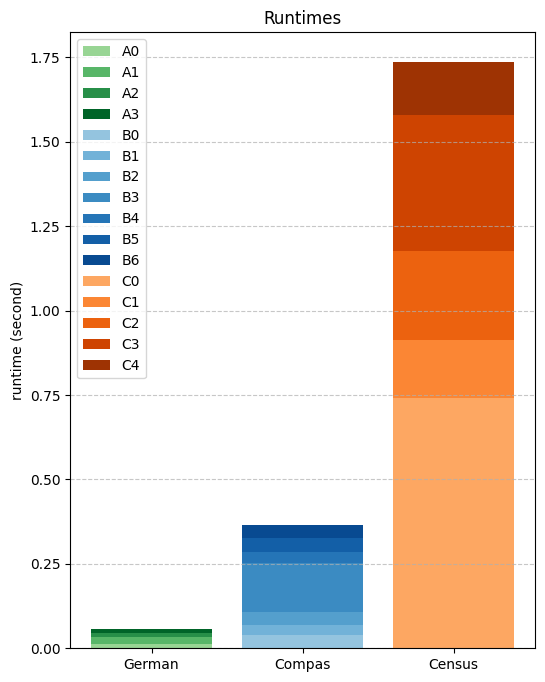

In [39]:
# No text version
import matplotlib.pyplot as plt
import numpy as np

data = [runtimes_A, runtimes_B, runtimes_C]
labels = ["German", "Compas", "Census"]
x = np.arange(len(labels))

cmaps = [plt.cm.Greens, plt.cm.Blues, plt.cm.Oranges]

plt.figure(figsize=(6, 8))

for j, runtimes in enumerate(data):
    bottom = 0
    cmap = cmaps[j]
    n = len(runtimes)
    for i, (key, value) in enumerate(runtimes.items()):
        color = cmap(0.4 + 0.5 * (i / (n - 1 if n > 1 else 1)))
        plt.bar(
            x[j],
            value,
            bottom=bottom,
            color=color,
            label=key
        )
        # plt.text(
        #     x[j],
        #     bottom + value / 2,
        #     key,
        #     ha="center",
        #     va="center",
        #     color="black",
        #     fontsize=9
        # )
        bottom += value

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(x, labels)
plt.legend()
plt.ylabel("runtime (second)")
plt.title("Runtimes")
plt.show()


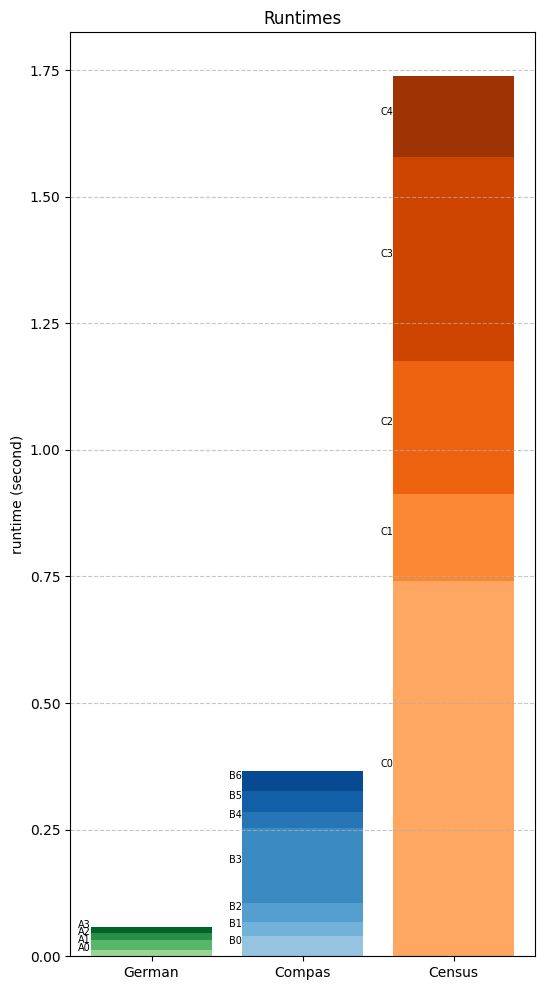

In [46]:
# Text version
import matplotlib.pyplot as plt
import numpy as np

data = [runtimes_A, runtimes_B, runtimes_C]
labels = ["German", "Compas", "Census"]
x = np.arange(len(labels))

cmaps = [plt.cm.Greens, plt.cm.Blues, plt.cm.Oranges]

plt.figure(figsize=(6, 12))

for j, runtimes in enumerate(data):
    bottom = 0
    cmap = cmaps[j]
    n = len(runtimes)
    for i, (key, value) in enumerate(runtimes.items()):
        color = cmap(0.4 + 0.5 * (i / (n - 1 if n > 1 else 1)))
        plt.bar(
            x[j],
            value,
            bottom=bottom,
            color=color,
            label=key
        )
        plt.text(
            x[j] - 0.4,
            bottom + value / 2,
            key,
            ha="right", 
            va="bottom",
            color="black",
            fontsize=7
        )
        bottom += value

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(x, labels)
plt.ylabel("runtime (second)")
plt.title("Runtimes")
plt.show()